# 24x — estimator-matched pseudo-Voigt forward model (Phase D1)

**Series 24 — real-data accuracy.** One change vs `24w`:

> **D1: the simulator's FWHM AND sigma_fit channels both come from the pseudo-Voigt estimator (22g best-matched; one pv fit per run) instead of the analytic Lorentzian CRLB, and the sigma channel is re-enabled (2-D KDE re-derived) with the B8 count-prior mu stabiliser kept. DO_FISHER off (C-phase frozen).**

Full context and the frozen protocol/metric are in `SERIES_STATE.md`. Baseline reference:
`experiment_6 trial_07` (24a) = **W_obj(all14) 0.0811, T≥40 0.0675, μ rel-RMSE 35.9 %, γ 22.3 %**, 0/14 divergences.


## Hypothesis / prediction — 24x (Phase D1)

- **Change vs previous notebook (`24w`):** the forward model is now **estimator-matched** — the simulator's
  FWHM **and** σ_fit channels both come from the **pseudo-Voigt** estimator (22g's best-matched: 13.8 % FWHM-IQR
  and 28.1 % σ_fit error vs real, against 45.2 % / 61.5 % for the unbinned Lorentzian MLE), produced by a
  **single** pv fit per run.  The σ channel is re-enabled (the 2-D KDE is re-derived) **and** the B8
  count-prior stabiliser is kept (new: it acts whenever `cnt_prior_w>0`, not only when σ is off).
  `DO_FISHER=False` (the C-phase uncertainty tools are frozen in `data/processed/24w_referee.json`).
- **Hypothesis (FM#8 / D1):** the whole μ residual is the σ(μ)-conditional mis-calibration of the *analytic
  Lorentzian CRLB*; matching the estimator at source (pv) removes it, so μ should land near truth, while the
  γ channel — which still consumes σ — may pay (24o's finding).
- **Falsifiable prediction:** μ rel-RMSE improves on 24r's 25.5 % and the per-cell μ/true table moves toward 1
  (especially high T, where the CRLB mismatch grows); **falsified if** μ is unchanged or worse — which would
  mean the estimator choice does not set the μ mode and the residual is a genuine photon/model gap (line
  shape, FM#6), not an estimator artefact.
- **If falsified:** the D1 lever is closed; escalate to a *calibrated* σ map (D2 surrogate / D3 per-cell table)
  and keep the 24r μ treatment.


## Panel (series-22 visual conventions)
- **FIG 1 (interactive, Plotly)** — per experiment: the **(mu, gamma) parameter path** (left) and the
  **generated (FWHM, sigma_fit) cloud at that step** (right) against the real data. Experiment dropdown +
  play button / slider over the iteration.
- **FIG 2 — the uncertainty report: μ on top, γ underneath** (one panel each, `hat/true` vs transmission
  with the CRB whiskers); the **hue is the laser power** (1nW | 3nW).
- **FIG 3** normalised trajectories `mu/mu_true`, `gamma/gamma_true` vs iteration (per power).
- **FIG 4** accuracy vs transmission (mu and gamma ratios, both powers, goal bands).

In [1]:
# ============================================================
# 23a — imports (repo bootstrap like the 22-series)
# ============================================================
import math, os, sys, time, json
from contextlib import nullcontext
import numpy as np
import torch
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE

torch.set_default_dtype(torch.float32)
for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p); REPO_ROOT = _p; break
os.chdir(REPO_ROOT)

from src.fitting import fit_profile, fwhm_from_theta, nll
from src.samplers import draw_fixed_noise
from src.implicit import compute_fwhm_and_dgamma

import plotly
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
pio.templates.default = 'plotly_white'
pio.renderers.default = os.environ.get('PLOTLY_RENDERER', 'vscode')
print('Imports OK | plotly', plotly.__version__, '| repo', REPO_ROOT)


Imports OK | plotly 7.1.0 | repo /home/pukky/.openclaw/workspace/qm-ml/notebooks/24_realdata_accuracy/../..


In [2]:
# ============================================================
# 23a — EXPERIMENTS (14 real; true values from Gregor's fits)
# ============================================================
EXPERIMENTS = [
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393,   sigma_prop=2.576,  lam=2.232, gamma_true=8.5,  n_target=61),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372,  sigma_prop=3.445,  lam=2.122, gamma_true=8.5,  n_target=358),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316,  sigma_prop=4.141,  lam=2.286, gamma_true=8.5,  n_target=1138),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405,  sigma_prop=7.198,  lam=2.351, gamma_true=8.5,  n_target=2428),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374,  sigma_prop=9.851,  lam=2.593, gamma_true=8.5,  n_target=2424),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365,  sigma_prop=12.627, lam=2.758, gamma_true=8.5,  n_target=2487),
    dict(name='1nW Trans100', power='1nW', mu_true=70.817,  sigma_prop=17.221, lam=2.636, gamma_true=8.5,  n_target=2455),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204,  sigma_prop=3.724,  lam=2.186, gamma_true=14.1, n_target=252),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476,  sigma_prop=5.639,  lam=2.158, gamma_true=14.1, n_target=1572),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279,  sigma_prop=8.319,  lam=2.264, gamma_true=14.1, n_target=2171),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892,  sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95,  lam=2.741, gamma_true=14.1, n_target=2541),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508),
    dict(name='3nW Trans100', power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516),
]
POWERS = ['1nW', '3nW']
TRANS  = ['05', '10', '20', '40', '60', '80', '100']
print(len(EXPERIMENTS), 'experiments')


14 experiments


In [3]:
# ============================================================
# 24a CONFIG — FROZEN experiment_6 trial_07 model (the series-24 baseline)
# ============================================================
NB_ID = '24x'
ONE_CHANGE = 'D1: the simulator\'s FWHM AND sigma_fit channels both come from the pseudo-Voigt estimator (22g best-matched; one pv fit per run) instead of the analytic Lorentzian CRLB, and the sigma channel is re-enabled (2-D KDE re-derived) with the B8 count-prior mu stabiliser kept. DO_FISHER off (C-phase frozen).'
DO_FISHER  = False     # C2 (24t): Fisher frozen in the C-phase; D1 is a point-estimate arm
DO_BOOTSTRAP = False   # C2 keeps C1 off (bootstrap read from data/processed/24s_bootstrap.json)
DO_PROFILE = False     # C3 off (profile read from data/processed/24u_profile.json)
DO_BIAS = False        # C4 off (bias read from data/processed/24v_bias.json)
DO_REFEREE = False     # C5 off (frozen in data/processed/24w_referee.json)

CFG = dict(
    mu_sched_shape='two_phase',                  # A7: 2x cap first half, 1/3 cap second half
    mu_tp_hi=2.0, mu_tp_lo=(1.0 / 3.0),          # the two per-step cap multipliers
    mu_lr_sign2=True,                            # A4: per-cell LR x clip(sigma_prop^2/s2_med, floor, cap)
    mu_lr_cap=2.0, mu_lr_floor=1.0,              # ... capped at 2x / floored at 1x the A2 LR
    mu_freeze=True, mu_freeze_frac=0.15,         # A5: stop mu when |grad| < frac * |grad_init|
    sigma_map='none',                            # B1/B2 map OFF (branch measured; base = 24g/24k)
    sw_sched='none',                             # B3 anneal OFF (branch measured)
    sigma_kernel='gauss',                        # B4 t-kernel OFF (branch measured)
    # (B5 sigma_estimator line superseded by sigma_estimator='pseudo_voigt_full' above)
    mu_reward='kde',                             # B6 OFF (branch measured)
    het_frac=0.0,                                # B7 OFF (branch measured)
    sigma_channel='on', cnt_prior_w=0.25,        # D1: 2-D KDE re-derived; B8 count prior kept
    sigma_estimator='pseudo_voigt_full',          # D1: FWHM + sigma_fit both from the pv estimator
    n_runs=100, n_iter=30,                       # series-21/exp5/6 protocol
    # FROZEN schedule = experiment_5 winning trial (trial_21)
    lr_mu=None, mu_anneal=0.0,                 # A2: lr_mu REPLACED by the per-exp travel calibration
    lr_gamma=0.4716, gamma_anneal=0.4723,      # gamma channel frozen
    sigma_ref=10.0, clip=float('inf'),           # no gradient clipping (21i)
    # FROZEN experiment_6 winner (trial_07)
    sigma_weight=0.8648862719598797,             # sigma-channel damping
    gamma_rel_cap=0.10735617789825944,           # relative gamma trust region
    h_f_scale=4.0, h_s_scale=3.674548492934102,  # inflated Scott bandwidths
    h_s_min=0.05,
)
H_REF = 1.0            # z-form gamma-score reference (optimizer only)
SEED  = 42             # per-step noise seed base (deterministic)
REAL_CSV = os.path.join(REPO_ROOT, 'data', 'processed', 'fwhm_linewidths.csv')

# ---- Fisher knobs (used ONLY when DO_FISHER is True) ----
M_FINAL, FISHER_SEEDS, FISHER_BASE_SEED = 150, 1, 7000   # C1: reduced for the bootstrap CRB compare

OUT_JSON = os.path.join(REPO_ROOT, 'data', 'processed', f'{NB_ID}_history.json')

SMOKE = os.environ.get('NB_SMOKE') == '1'
if SMOKE:
    CFG['n_runs'], CFG['n_iter'] = 20, 4
    EXPERIMENTS = EXPERIMENTS[4:5]
    M_FINAL, FISHER_SEEDS = 40, 1
CACHED = (not SMOKE) and os.path.exists(OUT_JSON) and os.environ.get('NB_RECOMPUTE') != '1'
print(f'{NB_ID} | one change: {ONE_CHANGE}')
print(f'config: {CFG}')
print(f'M_FINAL={M_FINAL}, seeds={FISHER_SEEDS} | DO_FISHER={DO_FISHER} | SMOKE={SMOKE} | CACHED={CACHED}')


24x | one change: D1: the simulator's FWHM AND sigma_fit channels both come from the pseudo-Voigt estimator (22g best-matched; one pv fit per run) instead of the analytic Lorentzian CRLB, and the sigma channel is re-enabled (2-D KDE re-derived) with the B8 count-prior mu stabiliser kept. DO_FISHER off (C-phase frozen).
config: {'mu_sched_shape': 'two_phase', 'mu_tp_hi': 2.0, 'mu_tp_lo': 0.3333333333333333, 'mu_lr_sign2': True, 'mu_lr_cap': 2.0, 'mu_lr_floor': 1.0, 'mu_freeze': True, 'mu_freeze_frac': 0.15, 'sigma_map': 'none', 'sw_sched': 'none', 'sigma_kernel': 'gauss', 'mu_reward': 'kde', 'het_frac': 0.0, 'sigma_channel': 'on', 'cnt_prior_w': 0.25, 'sigma_estimator': 'pseudo_voigt_full', 'n_runs': 100, 'n_iter': 30, 'lr_mu': None, 'mu_anneal': 0.0, 'lr_gamma': 0.4716, 'gamma_anneal': 0.4723, 'sigma_ref': 10.0, 'clip': inf, 'sigma_weight': 0.8648862719598797, 'gamma_rel_cap': 0.10735617789825944, 'h_f_scale': 4.0, 'h_s_scale': 3.674548492934102, 'h_s_min': 0.05}
M_FINAL=150, seeds=1 |

In [4]:
# ============================================================
# 23a — helpers (verbatim from experiment_6/ag_hypopt.py, plus a gamma_scale switch)
# ============================================================
GAMMA_SCALE = True     # optimizer uses the z-form gamma-score; the Fisher sets this False

def _kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop, cfg):
    '''2-D KDE log-likelihood pieces + per-DATA-POINT scores (as exp5/6).'''
    # --- B1 (24k): sigma-remap.  Apply the monotone map f to sim_s and, by the chain rule,
    #     to sim_ds (piecewise-linear f => piecewise-constant f').  Ranking is preserved.
    _sm = cfg.get('_sigma_map')
    if _sm is not None:
        _raw = sim_s.detach().cpu().numpy()
        if _sm['mode'] == 'quantile':
            _xs, _ys, _sl = _sm['xs'], _sm['ys'], _sm['sl']
            _mapped = np.interp(_raw, _xs, _ys)
            _ii = np.clip(np.searchsorted(_xs, _raw, side='right') - 1, 0, len(_sl) - 1)
            _fac = _sl[_ii]
        else:                                            # 'scale': f(x) = a*x (B2 control)
            _mapped = _sm['a'] * _raw; _fac = np.full(_raw.shape, _sm['a'])
        sim_s = torch.as_tensor(_mapped, dtype=sim_s.dtype)
        sim_ds = torch.as_tensor(_fac, dtype=sim_ds.dtype) * sim_ds
    sw = float(cfg.get('sigma_weight', 1.0))
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    # --- B4 (24n): sigma-channel kernel switch.  gauss (frozen) | student_t (heavy tailed).
    #   log K_s = -((nu+1)/2) log(1 + sw * t / nu)   with t = (d_s/h_s)^2;  nu -> inf  =  gauss.
    #   The exact dlogK_s/dgamma in the frozen z-form carries the factor rho (-> 1 as nu -> inf).
    _t = (d_s / h_s) ** 2
    if str(cfg.get('sigma_channel', 'on')) == 'off':
        # --- B8 (24r): 1-D FWHM-only KDE.  The sigma channel is removed from the reward AND
        #     from the gamma chain (rho=0 kills the d_s*sim_ds term).  Truth-free.
        W = torch.exp(-0.5 * (d_f / h_f) ** 2)
        _rho = torch.zeros_like(_t)
    elif str(cfg.get('sigma_kernel', 'gauss')) == 'student_t':
        _nu = float(cfg.get('sigma_t_nu', 3.0))
        W = torch.exp(-0.5 * (d_f / h_f) ** 2) * (1.0 + sw * _t / _nu) ** (-0.5 * (_nu + 1.0))
        _rho = ((_nu + 1.0) / _nu) / (1.0 + sw * _t / _nu)
    else:
        W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * sw * _t)
        _rho = torch.ones_like(_t)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    if GAMMA_SCALE:
        dlogG = ((d_f * sim_df[None, :]) / h_f + sw * _rho * (d_s * sim_ds[None, :]) / h_s) / H_REF
    else:
        dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + sw * _rho * (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    return s_mu, s_gamma, -logp.mean(), w, W

def _fit_fn(ph):  return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
# --- B5 (24o): the estimator-matched (pseudo-Voigt) fits, used for the SIGMA channel only ---
def _fit_pv(ph):   return fit_profile(ph, n_iters=80, model='pseudo-voigt', uniform_bg=False)
def _fwhm_pv(th):  return fwhm_from_theta(th, model='pseudo-voigt')
def _nll_pv(th, ph): return nll(th, ph, model='pseudo-voigt', uniform_bg=False)
def _fwhm_fn(th): return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph): return nll(th, ph, model='lorentzian', uniform_bg=False)

def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)

# --- B6 (24p): exp8's cvm_fwhm per-run loss (Cramer-von Mises squared-quantile, FWHM only) ---
def _sorted_target(t): return torch.sort(t)[0]

def _quantile_match(sim_vals, tgt_sorted):
    B = sim_vals.shape[0]; M = tgt_sorted.shape[0]
    sv, idx = torch.sort(sim_vals)
    pos = ((torch.arange(B, dtype=torch.float32) + 0.5) / B) * (M - 1)
    lo = torch.floor(pos).long().clamp(0, M - 1); hi = torch.clamp(lo + 1, max=M - 1)
    frac = pos - lo.float()
    matched = tgt_sorted[lo] * (1.0 - frac) + tgt_sorted[hi] * frac
    return sv, matched, idx

def _quantile_loss(sim_vals, sim_dvals, tgt_sorted, power=2):
    B = sim_vals.shape[0]
    sv, matched, idx = _quantile_match(sim_vals, tgt_sorted)
    d = sv - matched
    l_s = d ** 2 if power == 2 else d.abs()
    g_s = (2.0 * d * sim_dvals[idx]) if power == 2 else (torch.sign(d) * sim_dvals[idx])
    out_l = torch.empty(B, dtype=sv.dtype); out_l[idx] = l_s
    out_g = torch.empty(B, dtype=sv.dtype); out_g[idx] = g_s
    return out_l, out_g

def _run_one_pv(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_pv, _fwhm_pv, _nll_pv, n_params=3)

def _init_worker(): torch.set_num_threads(1)
def _parallel_map(pool, tasks, fn=None): return list(pool.map(fn or _run_one, tasks, chunksize=8))

def _load_real_target(exp):
    '''Real measured target for `exp` (15-series convention): raw*1000 -> MHz, keep err/fwhm < 10.'''
    import pandas as pd
    power_nW = int(str(exp['power']).replace('nW', ''))
    trans = int(str(exp['name']).split('Trans')[-1])
    df = pd.read_csv(REAL_CSV)
    sub = df[(df['power_nW'] == power_nW) & (df['transmission'] == trans)]
    f = sub['fwhm'].to_numpy(dtype=float) * 1000.0
    e = sub['fit_error'].to_numpy(dtype=float) * 1000.0
    with np.errstate(invalid='ignore', divide='ignore'):
        ok = np.isfinite(f) & np.isfinite(e) & (f > 0)
        filt = ok & ((e / f) < 10.0)
    return (torch.tensor(f[filt], dtype=torch.float32), torch.tensor(e[filt], dtype=torch.float32))

def _bandwidths(target_f, target_s, h_f_scale, h_s_scale, h_s_min):
    '''Scott-from-target, scaled (FIXED w.r.t. mu,gamma -> a clean likelihood).'''
    scott = len(target_f) ** (-1.0 / 6.0)
    H_F = h_f_scale * float(target_f.std()) * scott
    H_S = max(h_s_scale * float(target_s.std()) * scott, h_s_min)
    return H_F, H_S

def _sims(pool, mu, sigma_prop, lam, gamma, n_runs, seed, sigma_est='lorentzian'):
    rng = np.random.default_rng(seed)
    tasks, ns = [], []
    for _ in range(n_runs):
        u, b, n = draw_fixed_noise(mu, sigma_prop, lam, rng)
        tasks.append((gamma, u.numpy(), b.numpy())); ns.append(n)
    # --- D1 (24x): FULL estimator match.  'pseudo_voigt_full' runs the pv fit ONCE per run and
    #     takes BOTH FWHM and sigma_fit (and their gamma derivatives) from it (one fit, not two).
    if str(sigma_est) == 'pseudo_voigt_full':
        res = _parallel_map(pool, tasks, fn=_run_one_pv)
    else:
        res = _parallel_map(pool, tasks)
    ft = torch.tensor([r[0] for r in res], dtype=torch.float32)
    st = torch.tensor([r[1] for r in res], dtype=torch.float32)
    dgt = torch.tensor([r[2] for r in res], dtype=torch.float32)
    dst = torch.tensor([r[3] for r in res], dtype=torch.float32)
    if str(sigma_est) == 'pseudo_voigt':
        # B5 (24o): take sigma_fit and dsigma/dgamma from the pseudo-Voigt fit on the SAME
        # photons (estimator-matched); FWHM and dFWHM/dgamma stay with the Lorentzian fit.
        rpv = _parallel_map(pool, tasks, fn=_run_one_pv)
        st = torch.tensor([r[1] for r in rpv], dtype=torch.float32)
        dst = torch.tensor([r[3] for r in rpv], dtype=torch.float32)
    return ft, st, torch.tensor(ns, dtype=torch.float32), dgt, dst

def _fisher_at(pool, mu, gamma, sigma_prop, lam, target_f, target_s, H_F, H_S, cfg):
    '''Fisher of the KDE likelihood at (mu,gamma): per-scan J and the data-scaled J.
       Returns dict with sigma_mu/sigma_gamma under the per-scan normalisation and the
       dataset correction sigma/sqrt(N).'''
    global GAMMA_SCALE
    gs = GAMMA_SCALE; GAMMA_SCALE = False          # Fisher uses the RAW likelihood chain
    N = int(len(target_f))
    Js = []; Ks = []
    try:
        for s_i in range(FISHER_SEEDS):
            ft, si_t, nt, dg_t, ds_t = _sims(pool, mu, sigma_prop, lam, gamma, M_FINAL, FISHER_BASE_SEED + s_i)
            s_mu, s_gamma, _, _, _ = _kde_scores(ft, si_t, nt, dg_t, ds_t,
                                                 target_f, target_s, H_F, H_S, mu, sigma_prop, cfg)
            s = torch.stack([s_mu, s_gamma], dim=1)
            Js.append(s.T @ s / N)                 # the EXISTING convention (per-scan)
            # --- C2 (24t): K = empirical CENTRED score covariance (per-scan normalisation) ---
            _sc = s - s.mean(dim=0, keepdim=True)
            Ks.append(_sc.T @ _sc / N)
    finally:
        GAMMA_SCALE = gs
    J_single = torch.stack(Js).mean(dim=0)
    K_single = torch.stack(Ks).mean(dim=0)
    inv_single = torch.linalg.inv(J_single + 1e-12 * torch.eye(2))
    inv_data = inv_single / N                      # dataset CRB = (N*J)^-1
    # --- C2 (24t): the SANDWICH  S = H^-1 K H^-1  vs the plain CRB J^-1 -------------------
    #   H = OBSERVED information = Hessian of the mean NLL of the SAME frozen likelihood,
    #   central differences with FRESH sim clouds.  The FD step is 0.7x the per-scan CRB sigma
    #   (truth-free: taken from the Fisher at this optimum, never from mu_true/gamma_true).
    HM = max(1e-3, 0.7 * float(math.sqrt(inv_single[0, 0])))
    HG = max(1e-3, 0.7 * float(math.sqrt(inv_single[1, 1])))
    gs2 = GAMMA_SCALE; GAMMA_SCALE = False
    def _nll_at(mu_, gm_):
        _ft, _si, _nt, _dg, _ds = _sims(pool, mu_, sigma_prop, lam, gm_, M_FINAL, FISHER_BASE_SEED + 500)
        return float(_kde_scores(_ft, _si, _nt, _dg, _ds, target_f, target_s, H_F, H_S, mu_, sigma_prop, cfg)[2])
    try:
        f0 = _nll_at(mu, gamma)
        Hmm = (_nll_at(mu - HM, gamma) - 2.0 * f0 + _nll_at(mu + HM, gamma)) / HM ** 2
        Hgg = (_nll_at(mu, gamma - HG) - 2.0 * f0 + _nll_at(mu, gamma + HG)) / HG ** 2
        Hmg = (_nll_at(mu + HM, gamma + HG) - _nll_at(mu + HM, gamma - HG)
               - _nll_at(mu - HM, gamma + HG) + _nll_at(mu - HM, gamma - HG)) / (4.0 * HM * HG)
    finally:
        GAMMA_SCALE = gs2
    H_obs = torch.tensor([[Hmm, Hmg], [Hmg, Hgg]], dtype=torch.float32)
    H_obs = 0.5 * (H_obs + H_obs.T)
    _ev = torch.linalg.eigvalsh(H_obs)
    if float(_ev.min()) <= 1e-9:
        H_obs = H_obs + (1e-6 - float(_ev.min())) * torch.eye(2)   # PSD floor (fragile observed info, FM#11)
    _invH = torch.linalg.inv(H_obs)
    sand_single = _invH @ K_single @ _invH
    sand_data = sand_single / N
    out = dict(N=N, J=J_single.tolist(), K=K_single.tolist(), H=H_obs.tolist(),
               sig_mu_single=float(math.sqrt(inv_single[0, 0])),
               sig_g_single=float(math.sqrt(inv_single[1, 1])),
               corr_single=float(inv_single[0, 1] / math.sqrt(inv_single[0, 0] * inv_single[1, 1])),
               sig_mu_data=float(math.sqrt(inv_data[0, 0])),
               sig_g_data=float(math.sqrt(inv_data[1, 1])),
               corr_data=float(inv_data[0, 1] / math.sqrt(inv_data[0, 0] * inv_data[1, 1])),
               sig_mu_sand_single=float(math.sqrt(max(sand_single[0, 0], 0.0))),
               sig_g_sand_single=float(math.sqrt(max(sand_single[1, 1], 0.0))),
               sig_mu_sand=float(math.sqrt(max(sand_data[0, 0], 0.0))),
               sig_g_sand=float(math.sqrt(max(sand_data[1, 1], 0.0))))
    return out

print('helpers ready')


helpers ready


In [5]:
# ============================================================
# 23a — one experiment: the FROZEN optimisation (exp6 mechanism), recording the path
# ============================================================
def run_experiment(exp, cfg, pool):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    lam, gamma_true = exp['lam'], exp['gamma_true']
    mu_init, gamma_init = 0.5 * mu_true, 0.5 * gamma_true
    n_runs, n_iter = cfg['n_runs'], cfg['n_iter']
    lr_gamma = cfg['lr_gamma']
    mu_anneal, gamma_anneal = cfg['mu_anneal'], cfg['gamma_anneal']
    gamma_rel_cap = cfg['gamma_rel_cap']; clip = cfg['clip']

    _ov = cfg.get('_target_override')            # C1 (24s): bootstrap target override
    target_f, target_s = _ov if _ov is not None else _load_real_target(exp)
    H_F, H_S = _bandwidths(target_f, target_s, cfg['h_f_scale'], cfg['h_s_scale'], cfg['h_s_min'])
    # --- B7 (24q): per-scan linewidth heterogeneity (20e HET_FRAC) ----------------------
    #   excess FWHM scatter calibrated from the REAL robust FWHM scale (truth-free); it is
    #   independent of gamma, so dFWHM/dgamma and dsigma/dgamma are untouched.
    _jit = float(cfg.get('het_frac', 0.0)) * float(
        torch.quantile(target_f, 0.75) - torch.quantile(target_f, 0.25)) / 1.349

    mu_val, gamma_val = float(mu_init), float(gamma_init)

    # --- A2 (24b): truth-free travel calibration -------------------------------------
    #  The protocol starts at mu_init, so the distance to cover is exactly mu_init.  Set the
    #  mu step = sign(grad) * (mu_init/n_iter): each cell travels exactly mu_init over the run.
    #  |grad| is measured ONCE at the init (truth-free: it uses only mu_init and the reward).
    _ft0, _si0, _nt0, _dg0, _ds0 = _sims(pool, mu_val, sigma_prop, lam, gamma_val, n_runs, SEED,
                                    sigma_est=cfg.get('sigma_estimator', 'lorentzian'))
    if _jit > 0.0:                                                       # B7
        _ft0 = _ft0 + _jit * torch.tensor(np.random.default_rng(SEED + 991).standard_normal(n_runs), dtype=torch.float32)
    # --- B1 (24k): build the monotone sigma-remap ONCE from the INIT reference cloud + the
    #   target cloud (truth-free).  'quantile': sorted quantile matching (shape); 'scale': a*x.
    _smap = None
    if str(cfg.get('sigma_map', 'none')) != 'none':
        if str(cfg['sigma_map']) == 'quantile':
            _q = np.linspace(0.0, 1.0, int(cfg.get('si_q', 65)))
            _xs = np.quantile(_si0.numpy().astype(np.float64), _q)
            _ys = np.quantile(target_s.numpy().astype(np.float64), _q)
            _dx = np.diff(_xs); _dx = np.where(_dx <= 0, 1e-9, _dx)
            _smap = dict(mode='quantile', xs=_xs, ys=_ys, sl=np.diff(_ys) / _dx)
        else:                                        # 'scale' (B2 control)
            _smap = dict(mode='scale',
                         a=float(np.median(target_s.numpy())) / max(float(np.median(_si0.numpy())), 1e-9))
        cfg = dict(cfg); cfg['_sigma_map'] = _smap
    # --- B3 (24m): sigma-channel weight anneal ----------------------------------------
    #   sw_k = sw_hi early -> sw_lo late (linear).  The KDE (reward + gamma score) is rebuilt
    #   with sw_k each step; the A2 travel calibration below is unchanged (truth-free).
    def _cfg_sw(k):
        if str(cfg.get('sw_sched', 'none')) != 'anneal':
            return cfg
        _sw = cfg['sw_hi'] + (cfg['sw_lo'] - cfg['sw_hi']) * (k / max(n_iter - 1, 1))
        _c = dict(cfg); _c['sigma_weight'] = _sw; return _c
    # --- B6 (24p): the MU reward is exp8's cvm_fwhm (squared-quantile, FWHM only) ---------
    _tgt_f_sorted = _sorted_target(target_f)
    _cvm_s = float(cfg.get('cvm_scale', 1.0))
    _W0 = _kde_scores(_ft0, _si0, _nt0, _dg0, _ds0, target_f, target_s,
                      H_F, H_S, mu_val, sigma_prop, _cfg_sw(0))[4]
    if str(cfg.get('mu_reward', 'kde')) == 'cvm_fwhm':
        _r0 = -_quantile_loss(_ft0, _dg0, _tgt_f_sorted, power=2)[0] * _cvm_s
    else:
        _r0 = torch.log(_W0.clamp_min(1e-30)).mean(dim=0)
    _score0 = (_nt0 - mu_val) / sigma_prop ** 2
    grad_mu_init = abs(float(-(_r0 - _r0.mean()) @ _score0))
    lr_mu_eff = (mu_init / n_iter) / max(grad_mu_init, 1e-12)   # equivalent fixed LR (diagnostic)
    # --- A4 (24d): per-cell mu LR \u221d sigma_prop^2 (23e), with cap/floor ----------------
    #  23e: the correct mu step scales like sigma_prop^2.  Multiply the A2 LR by
    #  clip(sigma_prop^2 / median_14(sigma_prop^2), floor, cap) -- truth-free (sigma_prop is a
    #  data/protocol quantity).  floor 1.0 protects the already-calibrated (small-sigma_prop)
    #  cells from being starved; cap 2.0 stops the largest-sigma_prop cells being over-driven.
    if cfg.get('mu_lr_sign2', False):
        _s2ref = float(np.median([e['sigma_prop'] ** 2 for e in EXPERIMENTS]))
        _g_lr = float(sigma_prop ** 2 / _s2ref)
        _g_lr = min(max(_g_lr, cfg['mu_lr_floor']), cfg['mu_lr_cap'])
    else:
        _g_lr = 1.0
    lr_mu_eff_e = lr_mu_eff * _g_lr               # the LR the step rule actually uses
    # --- A3 (24c): cosine-shaped per-step travel, SAME total travel -------------------
    #  A2's total budget (sum_k c_k = mu_init) is kept EXACTLY; only its DISTRIBUTION
    #  over the run changes: c_k = (mu_init/n_iter)*shape_k, sum_k shape_k = n_iter.
    _shape_mode = cfg.get('mu_sched_shape', 'constant')
    _kk = np.arange(n_iter)
    if _shape_mode == 'cosine':
        _shape = 1.0 + np.cos(np.pi * _kk / max(n_iter - 1, 1))    # front-loaded, mean 1
    elif _shape_mode == 'two_phase':
        _shape = np.where(_kk < n_iter // 2, cfg['mu_tp_hi'], cfg['mu_tp_lo'])  # explore / damp
    else:
        _shape = np.ones(n_iter)
    _shape = _shape * n_iter / _shape.sum()                    # normalise: sum -> n_iter
    mu_step_k = (mu_init / n_iter) * _shape                    # per-step travel CAP, sum_k = mu_init
    mu_step = mu_init / n_iter                                 # A2 reference cap (diagnostic)
    # ---------------------------------------------------------------------------------
    history, diverged, diverged_at = [], False, None
    t0 = time.time()
    for step in range(n_iter):
        ft, si_t, nt, dg_t, ds_t = _sims(pool, mu_val, sigma_prop, lam, gamma_val, n_runs, SEED + step,
                                            sigma_est=cfg.get('sigma_estimator', 'lorentzian'))
        if _jit > 0.0:                                                   # B7
            ft = ft + _jit * torch.tensor(np.random.default_rng(SEED + 991 + step).standard_normal(n_runs), dtype=torch.float32)
        _, s_gamma, nll_val, w, W = _kde_scores(ft, si_t, nt, dg_t, ds_t,
                                                target_f, target_s, H_F, H_S, mu_val, sigma_prop, cfg)
        if str(cfg.get('mu_reward', 'kde')) == 'cvm_fwhm':              # B6: cvm_fwhm | KDE
            r = -_quantile_loss(ft, dg_t, _tgt_f_sorted, power=2)[0] * _cvm_s
        else:
            r = torch.log(W.clamp_min(1e-30)).mean(dim=0)             # Anuar's reward
        score = (nt - mu_val) / sigma_prop ** 2                       # sigma_prop score
        grad_mu = float(-(r - r.mean()) @ score)
        grad_gamma = float(-s_gamma.mean())
        # A5 (24e): truth-free convergence freeze -- once |grad_mu| < frac*|grad_mu_init|,
        # STOP updating mu (the cell has reached its stationary point; further steps only wander).
        frozen = bool(cfg.get('mu_freeze', False)) and (abs(grad_mu) < cfg['mu_freeze_frac'] * grad_mu_init)
        _dmu = lr_mu_eff_e * grad_mu
        if float(cfg.get('cnt_prior_w', 0.0)) > 0.0:
            # --- B8 (24r): the COUNT CHANNEL re-added as a PRIOR ----------------------------
            #   (D1: trigger generalised from 'sigma channel off' to cnt_prior_w>0 so the
            #    stabiliser also acts when the estimator-matched sigma channel is ON.)
            #  mu is proportional to the photon count nbar, so the count channel is a statement
            #  about mu; on real data it carries no measurable count (19b: dead), so its only
            #  information is the protocol's own init.  A Gaussian prior N(mu_init, mu_init^2)
            #  has gradient -(mu-mu_init)/mu_init^2; a REINFORCE reward cannot see a mu-only
            #  constant, so the prior acts DIRECTLY on the update, at most cnt_prior_w * step.
            _dmu = _dmu + float(cfg.get('cnt_prior_w', 0.25)) * _shape[step] * (
                -(mu_val - mu_init) / max(mu_init, 1e-9))
        if not frozen:
            mu_val -= float(np.clip(_dmu, -mu_step_k[step], mu_step_k[step]))
        dgamma = lr_gamma * (1.0 - gamma_anneal * step / n_iter) * grad_gamma
        lim = gamma_rel_cap * abs(gamma_val)
        dgamma = max(-lim, min(lim, dgamma))
        gamma_val -= dgamma
        history.append(dict(step=step, mu=float(mu_val), gamma=float(gamma_val), nll=float(nll_val),
                            grad_mu=grad_mu, grad_gamma=grad_gamma, frozen=bool(frozen),
                            f=[round(float(x), 3) for x in ft], s=[round(float(x), 3) for x in si_t]))
        if not (0.2 <= mu_val <= 1500.0) or not (0.02 <= gamma_val <= 500.0):
            diverged = True; diverged_at = step; break
    return dict(exp=exp['name'], power=exp['power'], mu_true=mu_true, gamma_true=gamma_true,
                lr_mu_eff=lr_mu_eff, lr_mu_eff_e=lr_mu_eff_e, lr_scale_g=_g_lr,
                grad_mu_init=grad_mu_init, mu_step=mu_step,
                mu_step_total=float(mu_step_k.sum()),
                sigma_prop=sigma_prop, lam=lam, n_target=int(len(target_f)),
                mu_init=mu_init, gamma_init=gamma_init,
                mu_final=history[-1]['mu'], gamma_final=history[-1]['gamma'],
                nll_final=history[-1]['nll'], history=history,
                target_f=[round(float(x), 3) for x in target_f], target_s=[round(float(x), 3) for x in target_s],
                H_F=H_F, H_S=H_S, diverged=diverged, diverged_at=diverged_at,
                t_elapsed=time.time() - t0)

print('run_experiment ready')


run_experiment ready


In [6]:
# ============================================================
# 23a — RUN: all 14 real experiments (the long cell)
# ============================================================
N_WORKERS = 4
CACHED = (not SMOKE) and os.path.exists(OUT_JSON) and os.environ.get('NB_RECOMPUTE') != '1'
RESULTS = []
if CACHED:
    RESULTS = json.load(open(OUT_JSON))['results']
    print(f'loaded {len(RESULTS)} experiments from {OUT_JSON} (set NB_RECOMPUTE=1 to recompute)')
t0 = time.time()
with (nullcontext() if CACHED else _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker)) as pool:
    for exp in EXPERIMENTS:
        if CACHED:
            continue
        r = run_experiment(exp, CFG, pool)
        RESULTS.append(r)
        print(f"  {r['exp']:13s} mu {r['mu_true']:7.2f} -> {r['mu_final']:7.2f} | "
              f"gamma {r['gamma_true']:5.2f} -> {r['gamma_final']:6.2f} | NLL {r['nll_final']:.3f} | "
              f"{r['t_elapsed']/60:.1f} min{'  DIVERGED' if r['diverged'] else ''}", flush=True)
print(f'\ntotal {len(RESULTS)} experiments in {(time.time()-t0)/60:.1f} min')


  1nW Trans05   mu    9.39 ->    8.71 | gamma  8.50 ->   2.52 | NLL 0.256 | 5.6 min


  1nW Trans10   mu   12.37 ->   10.71 | gamma  8.50 ->   1.12 | NLL 0.373 | 5.4 min


  1nW Trans20   mu   17.32 ->   13.75 | gamma  8.50 ->   1.91 | NLL 0.676 | 5.4 min


  1nW Trans40   mu   38.41 ->   25.74 | gamma  8.50 ->   3.57 | NLL 0.835 | 5.3 min


  1nW Trans60   mu   61.37 ->   36.58 | gamma  8.50 ->   3.85 | NLL 0.909 | 5.2 min


...

  3nW Trans40   mu   84.89 ->   68.49 | gamma 14.10 ->   7.02 | NLL 0.791 | 7.4 min


  3nW Trans60   mu  103.20 ->   70.04 | gamma 14.10 ->   8.06 | NLL 0.743 | 10.1 min


  3nW Trans80   mu  137.54 ->  115.41 | gamma 14.10 ->   8.19 | NLL 0.740 | 10.2 min


  3nW Trans100  mu  175.71 ->  111.87 | gamma 14.10 ->   8.56 | NLL 0.790 | 8.3 min



total 14 experiments in 92.7 min


In [7]:
# ============================================================
# SERIES 24 / C1 (24s) — EMPIRICAL DATA BOOTSTRAP
#   Resample the RETAINED real scans (with replacement), re-run the FROZEN optimiser on each
#   resample, and report an honest per-cell interval for mu/gamma.  Budget reduction recorded
#   in the verdict/history: BOOT_EXPS = 8 exps (T05/20/60/100 x 1nW/3nW), B = 10.
# ============================================================
BOOT_T = [5, 20, 60, 100]
BOOT_EXPS = [e['name'] for e in EXPERIMENTS if int(str(e['name']).split('Trans')[-1]) in BOOT_T]
B_BOOT = 2 if SMOKE else 10
BOOT = {}
if DO_BOOTSTRAP:
    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker) as _bpool:
        for enm in BOOT_EXPS:
            exp = next(e for e in EXPERIMENTS if e['name'] == enm)
            tf_full, ts_full = _load_real_target(exp)
            N = int(len(tf_full))
            rng = np.random.default_rng(SEED + 31337)
            mus, gams = [], []
            for b in range(B_BOOT):
                idx = torch.tensor(rng.integers(0, N, size=N), dtype=torch.long)
                c2 = dict(CFG); c2['_target_override'] = (tf_full[idx], ts_full[idx])
                rb = run_experiment(exp, c2, _bpool)
                mus.append(rb['mu_final']); gams.append(rb['gamma_final'])
            mus = np.array(mus); gams = np.array(gams)
            rr = next(r for r in RESULTS if r['exp'] == enm)
            fr = _fisher_at(_bpool, rr['mu_final'], rr['gamma_final'], rr['sigma_prop'], rr['lam'],
                            tf_full, ts_full, rr['H_F'], rr['H_S'], CFG)
            BOOT[enm] = dict(mu=[round(float(x), 3) for x in mus], gamma=[round(float(x), 3) for x in gams],
                             mu_lo=float(np.percentile(mus, 2.5)), mu_hi=float(np.percentile(mus, 97.5)),
                             g_lo=float(np.percentile(gams, 2.5)), g_hi=float(np.percentile(gams, 97.5)),
                             mu_sd=float(mus.std()), g_sd=float(gams.std()),
                             crb_mu=float(fr['sig_mu_data']), crb_g=float(fr['sig_g_data']),
                             mu_true=exp['mu_true'], gamma_true=exp['gamma_true'])
            print(f"  {enm:13s} mu_true {exp['mu_true']:7.2f} | boot mu sd {mus.std():6.2f} "
                  f"[{BOOT[enm]['mu_lo']:7.2f},{BOOT[enm]['mu_hi']:7.2f}] | CRB_mu {fr['sig_mu_data']:6.2f} "
                  f"| ratio boot/CRB {mus.std()/max(fr['sig_mu_data'],1e-9):5.2f}", flush=True)
    _bcov = sum(1 for v in BOOT.values() if v['mu_lo'] <= v['mu_true'] <= v['mu_hi'])
    _bcvg = sum(1 for v in BOOT.values() if v['g_lo'] <= v['gamma_true'] <= v['g_hi'])
    _rt = float(np.median([v['mu_sd'] / max(v['crb_mu'], 1e-9) for v in BOOT.values()]))
    print(f"bootstrap 95% coverage (subset N={len(BOOT)}): mu {_bcov}/{len(BOOT)} | gamma {_bcvg}/{len(BOOT)}")
    print(f"median bootstrap-sd / dataset-CRB (mu) = {_rt:.2f}")
    if not SMOKE:
        _bout = os.path.join(REPO_ROOT, 'data', 'processed', '24s_bootstrap.json')
        json.dump(dict(notebook=NB_ID, subset=BOOT_EXPS, B=B_BOOT,
                       coverage_mu=_bcov, coverage_gamma=_bcvg, median_ratio=_rt, boot=BOOT),
                  open(_bout, 'w'))
        print('saved', _bout)
else:
    print('DO_BOOTSTRAP=False - bootstrap block skipped')


DO_BOOTSTRAP=False - bootstrap block skipped


In [8]:
# ============================================================
# SERIES 24 — FROZEN PROTOCOL METRIC (identical in every series-24 notebook)
#   T-weighted objective (exp5/6 definition): per-cell rel-sq error capped at CAP,
#   weight w(T) = W_FLOOR + (1-W_FLOOR)*T/100.  Lower = better.
# ============================================================
CAP, W_FLOOR = 1.0, 0.25
def tw_objective(results, Ts=None):
    rows = []
    for r in results:
        T = int(str(r['exp']).split('Trans')[-1])
        if Ts is not None and T not in Ts:
            continue
        em = min(((r['mu_final'] - r['mu_true']) / r['mu_true']) ** 2, CAP)
        eg = min(((r['gamma_final'] - r['gamma_true']) / r['gamma_true']) ** 2, CAP)
        w  = W_FLOOR + (1.0 - W_FLOOR) * T / 100.0
        rows.append((w, em, eg))
    if not rows:
        return float('nan')
    wts  = np.array([x[0] for x in rows] * 2)
    errs = np.array([x[1] for x in rows] + [x[2] for x in rows])
    return float((wts * errs).sum() / wts.sum())

OBJ_ALL = tw_objective(RESULTS)
OBJ_HI  = tw_objective(RESULTS, Ts={40, 60, 80, 100})
OBJ_LO  = tw_objective(RESULTS, Ts={5, 10, 20})
MU_RMSE = float(np.sqrt(np.mean([((r['mu_final'] - r['mu_true']) / r['mu_true']) ** 2 for r in RESULTS]))) * 100
G_RMSE  = float(np.sqrt(np.mean([((r['gamma_final'] - r['gamma_true']) / r['gamma_true']) ** 2 for r in RESULTS]))) * 100
N_DIV   = int(sum(bool(r['diverged']) for r in RESULTS))
print('=' * 74)
print(f'FROZEN METRIC ({NB_ID})   W_obj(all14) = {OBJ_ALL:.4f} | T>=40 {OBJ_HI:.4f} | T<=20 {OBJ_LO:.4f}')
print(f'                          mu rel-RMSE {MU_RMSE:.1f}% | gamma rel-RMSE {G_RMSE:.1f}% | diverged {N_DIV}/14')
print('=' * 74)
print(f"{'exp':14s}{'mu_true':>9s}{'mu_fit':>9s}{'mu/true':>9s} | {'gam_true':>9s}{'gam_fit':>9s}{'gam/true':>9s}")
for r in RESULTS:
    print(f"{r['exp']:14s}{r['mu_true']:9.2f}{r['mu_final']:9.2f}{r['mu_final']/r['mu_true']:9.3f} | "
          f"{r['gamma_true']:9.2f}{r['gamma_final']:9.2f}{r['gamma_final']/r['gamma_true']:9.3f}"
          f"{'   DIV' if r['diverged'] else ''}")
print()
print(f"{'T':>6}{'mu(1nW)':>10}{'mu(3nW)':>10}{'gam(1nW)':>11}{'gam(3nW)':>11}")
for T in sorted({int(str(r['exp']).split('Trans')[-1]) for r in RESULTS}):
    vals = []
    for p in POWERS:
        rs = [r for r in RESULTS if r['power'] == p and int(str(r['exp']).split('Trans')[-1]) == T]
        vals.append(round(rs[0]['mu_final'] / rs[0]['mu_true'], 3) if rs else float('nan'))
    for p in POWERS:
        rs = [r for r in RESULTS if r['power'] == p and int(str(r['exp']).split('Trans')[-1]) == T]
        vals.append(round(rs[0]['gamma_final'] / rs[0]['gamma_true'], 3) if rs else float('nan'))
    print(f"{T:>6}{vals[0]:>10}{vals[1]:>10}{vals[2]:>11}{vals[3]:>11}")


FROZEN METRIC (24x)   W_obj(all14) = 0.1953 | T>=40 0.1597 | T<=20 0.3044
                          mu rel-RMSE 27.1% | gamma rel-RMSE 61.4% | diverged 0/14
exp             mu_true   mu_fit  mu/true |  gam_true  gam_fit gam/true
1nW Trans05        9.39     8.71    0.927 |      8.50     2.52    0.297
1nW Trans10       12.37    10.71    0.866 |      8.50     1.12    0.131
1nW Trans20       17.32    13.75    0.794 |      8.50     1.91    0.225
1nW Trans40       38.41    25.74    0.670 |      8.50     3.57    0.420
1nW Trans60       61.37    36.58    0.596 |      8.50     3.85    0.453
1nW Trans80       79.36    58.96    0.743 |      8.50     4.22    0.497
1nW Trans100      70.82    50.34    0.711 |      8.50     4.34    0.511
3nW Trans05       13.20    11.17    0.846 |     14.10     1.94    0.137
3nW Trans10       24.48    16.48    0.673 |     14.10     4.08    0.290
3nW Trans20       34.28    22.79    0.665 |     14.10     6.49    0.460
3nW Trans40       84.89    68.49    0.807 |     14.

In [9]:
# ============================================================
# SERIES 24 — DIAGNOSTIC (new): step accounting — is the CLIP/budget or the LR the binding constraint?
#   per cell: the A2 reference cap, the RAW step lr_mu_eff*|grad_k| (median/max), the number of steps
#   where the clip actually binds (raw > cap/step-cap), and the realised NET travel in units of mu_init.
# ============================================================
print(f"{'exp':14s}{'cap':>8s}{'raw_med':>9s}{'raw_max':>9s}{'clip':>8s}{'net/init':>10s}{'flips':>7s}")
_net, _clip, _raw = [], [], []
for r in RESULTS:
    h = r['history']
    cap = r['mu_step']                                  # A2 reference per-step cap = mu_init/n_iter
    lre = r.get('lr_mu_eff_e', r['lr_mu_eff'])          # effective LR (A4-scaled when present)
    raw = [abs(lre * s['grad_mu']) for s in h]
    cl  = sum(1 for x in raw if x > cap)
    mus = [r['mu_init']] + [s['mu'] for s in h]
    net = mus[-1] - mus[0]
    flips = sum(1 for i in range(1, len(h)) if h[i]['grad_mu'] * h[i - 1]['grad_mu'] < 0)
    _net.append(abs(net) / r['mu_init']); _clip.append(cl); _raw.append(sorted(raw)[len(raw) // 2] / cap)
    print(f"{r['exp']:14s}{cap:8.3f}{sorted(raw)[len(raw)//2]:9.3f}{max(raw):9.3f}"
          f"{cl:5d}/{len(h):<2d}{net/r['mu_init']:10.2f}{flips:7d}")
print(f"\nmedian realised |net travel| = {np.median(_net):.2f} x mu_init | "
      f"median clipped steps = {np.median(_clip):.0f}/{CFG['n_iter']} | median raw/cap = {np.median(_raw):.2f}")
_mrc = float(np.median(_raw))
print("=> median raw/cap = %.2f: %s" % (_mrc, "the CLIP is mostly IDLE -> the LR is the binding constraint"
      if _mrc < 1 else "the CLIP binds on the median step -> the travel BUDGET is the binding constraint"))
print("   (realised |net travel| %.2f x mu_init: <<1 means the cells under-travel / under-shoot)" % float(np.median(_net)))


exp                cap  raw_med  raw_max    clip  net/init  flips
1nW Trans05      0.157    0.096    0.184    3/30      0.85      0
1nW Trans10      0.206    0.103    0.237    3/30      0.73      0
1nW Trans20      0.289    0.120    0.289    0/30      0.59      0
1nW Trans40      0.640    0.155    0.905    4/30      0.34      0
1nW Trans60      1.023    0.150    1.194    1/30      0.19      0
1nW Trans80      1.323    0.419   16.625    8/30      0.49      6
1nW Trans100     1.180    0.723    3.727    7/30      0.42      0
3nW Trans05      0.220    0.127    0.220    0/30      0.69      0
3nW Trans10      0.408    0.127    0.408    0/30      0.35      0
3nW Trans20      0.571    0.164    0.571    0/30      0.33      0
3nW Trans40      1.415    1.063    6.768   14/30      0.61      0
3nW Trans60      1.720    0.251    3.679   11/30      0.36      0
3nW Trans80      2.292    2.940  122.542   18/30      0.68      6
3nW Trans100     2.928    0.508    5.857    3/30      0.27      4

median re

In [10]:
# ============================================================
# SERIES 24 — FISHER at each optimum (ONLY when DO_FISHER):
#   (A) per-scan normalisation J = sum/N   -> sigma_*_single   (the historic convention)
#   (B) dataset correction  sig/sqrt(N)    -> sigma_*_data     (the whole experiment)
# ============================================================
t0 = time.time()
if not DO_FISHER:
    print('DO_FISHER=False - Fisher block skipped (series-24 point-estimate notebook)')
elif CACHED and all('fisher_frozen' in r for r in RESULTS):
    print('fisher block: cached')
else:
    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker) as pool:
        for r in RESULTS:
            exp = next(e for e in EXPERIMENTS if e['name'] == r['exp'])
            tf = torch.tensor(r['target_f'], dtype=torch.float32)
            ts = torch.tensor(r['target_s'], dtype=torch.float32)
            r['fisher_frozen'] = _fisher_at(pool, r['mu_final'], r['gamma_final'], r['sigma_prop'],
                                            r['lam'], tf, ts, r['H_F'], r['H_S'], CFG)
            print(f"  {r['exp']:13s} N={r['n_target']:5d} | sig_mu per-scan "
                  f"{r['fisher_frozen']['sig_mu_single']:8.1f} -> dataset {r['fisher_frozen']['sig_mu_data']:7.2f}",
                  flush=True)
    print(f'fisher block: {(time.time()-t0)/60:.1f} min')


DO_FISHER=False - Fisher block skipped (series-24 point-estimate notebook)


In [11]:
# ============================================================
# SERIES 24 / C3 (24u) — PROFILE-LIKELIHOOD INTERVAL FOR mu
#   Scan mu at fixed gamma=gamma_hat on a truth-free grid around the optimum, evaluate the
#   SAME frozen KDE NLL (sigma-channel state inherited), and find the Delta(-2 logL) =
#   2*N*(NLL(mu) - NLL_min) <= 1 interval (= 1 sigma, 1 d.o.f.).  Budget reduction (recorded):
#   13 grid points at +/-5 dataset-CRB sigmas, 2 sim seeds averaged per point.
# ============================================================
PROFILE_PTS, PROFILE_SEEDS, PROFILE_HALFWIDTH = 13, 2, 5.0
PROF = {}
if DO_PROFILE:
    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker) as _ppool:
        for r in RESULTS:
            exp = next(e for e in EXPERIMENTS if e['name'] == r['exp'])
            tf_pp = torch.tensor(r['target_f'], dtype=torch.float32)
            ts_pp = torch.tensor(r['target_s'], dtype=torch.float32)
            H_Fp, H_Sp = r['H_F'], r['H_S']
            mu_hat, g_hat = float(r['mu_final']), float(r['gamma_final'])
            fr = r.get('fisher_frozen') or {}
            _sp = float(fr.get('sig_mu_data') or (0.15 * abs(mu_hat)))
            _sp = max(_sp, 1e-6)
            grid = np.clip(mu_hat + np.linspace(-PROFILE_HALFWIDTH, PROFILE_HALFWIDTH, PROFILE_PTS) * _sp, 0.05, 1500.0)
            Npp = int(len(tf_pp))
            nll_g = np.zeros(PROFILE_PTS)
            for gi, mg in enumerate(grid):
                _acc = 0.0
                for si in range(PROFILE_SEEDS):
                    _ft, _si, _nt, _dg, _ds = _sims(_ppool, float(mg), r['sigma_prop'], r['lam'], g_hat,
                                                     CFG['n_runs'], SEED + 777 + si)
                    _acc += float(_kde_scores(_ft, _si, _nt, _dg, _ds, tf_pp, ts_pp, H_Fp, H_Sp,
                                              float(mg), r['sigma_prop'], CFG)[2])
                nll_g[gi] = _acc / PROFILE_SEEDS
            d2 = 2.0 * Npp * (nll_g - nll_g.min())          # Delta(-2 logL), total-likelihood scale
            _amin = int(np.argmin(d2))
            # robust readout: least-squares quadratic through the minimum, d2 ~ a*(mu-mu_min)^2
            _dm = grid - grid[_amin]
            _den = float(np.sum(_dm ** 4))
            _a = float(np.sum(d2 * _dm ** 2) / _den) if _den > 0 else float('nan')
            sig_prof = float(1.0 / np.sqrt(_a)) if _a > 0 else float('nan')
            lo = hi = float('nan')
            for gi in range(PROFILE_PTS - 1):
                d0, d1 = d2[gi], d2[gi + 1]
                if (d0 - 1.0) * (d1 - 1.0) < 0.0:
                    _f = (1.0 - d0) / (d1 - d0)
                    _x = float(grid[gi] + _f * (grid[gi + 1] - grid[gi]))
                    if gi < _amin:
                        lo = _x
                    else:
                        hi = _x
            PROF[r['exp']] = dict(mu_hat=mu_hat, gamma_hat=g_hat, N=Npp,
                                  grid=[round(float(x), 4) for x in grid],
                                  d2=[round(float(x), 4) for x in d2], lo=lo, hi=hi, sig_prof=sig_prof,
                                  sig_mu_data=fr.get('sig_mu_data'), sig_mu_single=fr.get('sig_mu_single'),
                                  mu_true=exp['mu_true'])
            _w = (hi - lo) if not (np.isnan(hi) or np.isnan(lo)) else float('nan')
            print(f"  {r['exp']:13s} mu_hat {mu_hat:7.2f} | profile [{lo:8.3f},{hi:8.3f}] (w {_w:6.3f}) "
                  f"| CRB_data {_sp:6.3f} | quad-sig {sig_prof:6.3f} | mu_true {exp['mu_true']:7.2f}", flush=True)
    _pcov = sum(1 for v in PROF.values()
                if not (np.isnan(v['lo']) or np.isnan(v['hi'])) and v['lo'] <= v['mu_true'] <= v['hi'])
    _pn = sum(1 for v in PROF.values() if not (np.isnan(v['lo']) or np.isnan(v['hi'])))
    _pw = [v['hi'] - v['lo'] for v in PROF.values() if not np.isnan(v['hi'])]
    print(f"profile 1-sigma (Delta=1) coverage of mu_true: {_pcov}/{_pn} resolved ({len(PROF)} cells total)")
    _qs = [v['sig_prof'] for v in PROF.values() if not np.isnan(v.get('sig_prof', float('nan')))]
    _qcov = sum(1 for v in PROF.values() if not np.isnan(v.get('sig_prof', float('nan')))
                and abs(v['mu_hat'] - v['mu_true']) <= 2.0 * v['sig_prof'])
    if _qs:
        print(f"quadratic-fit profile sigma: median {float(np.median(_qs)):.3f} | 2-sigma coverage of mu_true "
              f"{_qcov}/{len(_qs)} | median ratio to dataset CRB "
              f"{float(np.median([v['sig_prof']/v['sig_mu_data'] for v in PROF.values() if v['sig_mu_data'] and not np.isnan(v.get('sig_prof',float('nan')))])):.2f}")
    if _pw:
        print(f"median Delta=1 profile width {float(np.median(_pw)):.3f} vs median dataset CRB "
              f"{float(np.median([v['sig_mu_data'] for v in PROF.values() if v['sig_mu_data']])):.3f}")
    else:
        print('NO profile interval resolved on the grid (Delta(-2logL) > 1 everywhere) -- see verdict')
    if not SMOKE:
        _out = os.path.join(REPO_ROOT, 'data', 'processed', '24u_profile.json')
        json.dump(dict(notebook=NB_ID, method='profile', pts=PROFILE_PTS, seeds=PROFILE_SEEDS,
                       halfwidth=PROFILE_HALFWIDTH, coverage_mu=_pcov, resolved=_pn, profile=PROF),
                  open(_out, 'w'))
        print('saved', _out)
else:
    print('DO_PROFILE=False - profile block skipped')


DO_PROFILE=False - profile block skipped


In [12]:
# ============================================================
# SERIES 24 / C4 (24v) — BIAS-CORRECTED CRB (sim-at-truth bias, 22b/22g)
#   Measure the estimator's bias on SELF-CONSISTENT data: draw a pseudo-data cloud at
#   (mu_true, gamma_true), run the SAME frozen optimiser on it, bias = mu_hat_sim - mu_true.
#   Then mu_corr = mu_hat_real - bias and re-check coverage vs the dataset CRB and the 24s
#   bootstrap.  NOTE: this is the only cell that reads mu_true/gamma_true -- it is the METHOD's
#   ingredient (the 22b/22g sim-at-truth correction), not a knob tuned against the truth.
# ============================================================
BIAS = {}
if DO_BIAS:
    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker) as _bp:
        for r in RESULTS:
            exp = next(e for e in EXPERIMENTS if e['name'] == r['exp'])
            Nb = int(r.get('n_target', 100))
            _fb, _sb, _nb, _dgb, _dsb = _sims(_bp, r['mu_true'], r['sigma_prop'], r['lam'],
                                               r['gamma_true'], Nb, SEED + 4242)
            _c2 = dict(CFG); _c2['_target_override'] = (_fb, _sb)
            rb = run_experiment(exp, _c2, _bp)
            BIAS[r['exp']] = dict(mu_hat_sim=rb['mu_final'], g_hat_sim=rb['gamma_final'],
                                  bias_mu=rb['mu_final'] - r['mu_true'],
                                  bias_gamma=rb['gamma_final'] - r['gamma_true'],
                                  mu_hat=r['mu_final'], gamma_hat=r['gamma_final'],
                                  mu_corr=r['mu_final'] - (rb['mu_final'] - r['mu_true']),
                                  g_corr=r['gamma_final'] - (rb['gamma_final'] - r['gamma_true']),
                                  mu_true=r['mu_true'], gamma_true=r['gamma_true'], N=Nb)
            print(f"  {r['exp']:13s} mu_true {r['mu_true']:7.2f} | sim_hat {rb['mu_final']:7.2f} "
                  f"| bias {rb['mu_final']-r['mu_true']:+7.2f} | real_hat {r['mu_final']:7.2f} "
                  f"-> corr {BIAS[r['exp']]['mu_corr']:7.2f}", flush=True)
    _bf = np.array([v['bias_mu'] for v in BIAS.values()]); _bg = np.array([v['bias_gamma'] for v in BIAS.values()])
    print(f"sim-at-truth bias: median mu {np.median(_bf):+.3f} (std {_bf.std():.3f}) | "
          f"median gamma {np.median(_bg):+.3f} (std {_bg.std():.3f})")
    _unc = np.array([abs(v['mu_hat'] - v['mu_true']) for v in BIAS.values()])
    _cor = np.array([abs(v['mu_corr'] - v['mu_true']) for v in BIAS.values()])
    print(f"|mu_true error|: raw mean {_unc.mean():.3f} -> corr mean {_cor.mean():.3f} "
          f"({'IMPROVED' if _cor.mean() < _unc.mean() else 'NOT improved'})")
    # coverage versus the dataset CRB (2 sigma): raw vs bias-corrected
    _crb = {r['exp']: float((r.get('fisher_frozen') or {}).get('sig_mu_data') or float('nan')) for r in RESULTS}
    _raw2 = sum(1 for k, v in BIAS.items() if abs(v['mu_hat'] - v['mu_true']) <= 2.0 * _crb.get(k, float('nan')))
    _cor2 = sum(1 for k, v in BIAS.items() if abs(v['mu_corr'] - v['mu_true']) <= 2.0 * _crb.get(k, float('nan')))
    print(f'2-sigma CRB coverage of mu: raw {_raw2}/{len(BIAS)} -> bias-corrected {_cor2}/{len(BIAS)}')
    try:
        _bs = json.load(open(os.path.join(REPO_ROOT, 'data', 'processed', '24s_bootstrap.json')))['boot']
        _nb = sum(1 for k in BIAS if k in _bs)
        _b2r = sum(1 for k, v in BIAS.items() if k in _bs and abs(v['mu_hat'] - v['mu_true']) <= 2.0 * _bs[k]['mu_sd'])
        _b2c = sum(1 for k, v in BIAS.items() if k in _bs and abs(v['mu_corr'] - v['mu_true']) <= 2.0 * _bs[k]['mu_sd'])
        print(f'2-sigma 24s-bootstrap coverage (subset {_nb}): raw {_b2r}/{_nb} -> corrected {_b2c}/{_nb}')
    except Exception as _e:
        print('bootstrap compare skipped:', _e)
    if not SMOKE:
        _bo = os.path.join(REPO_ROOT, 'data', 'processed', '24v_bias.json')
        json.dump(dict(notebook=NB_ID, method='sim_at_truth_bias', bias=BIAS,
                       median_bias_mu=float(np.median(_bf)), median_bias_gamma=float(np.median(_bg)),
                       raw_abs_err_mean=float(_unc.mean()), corr_abs_err_mean=float(_cor.mean())),
                  open(_bo, 'w'))
        print('saved', _bo)
else:
    print('DO_BIAS=False - bias block skipped')


DO_BIAS=False - bias block skipped


In [13]:
# ============================================================
# SERIES 24 / C5 (24w) — COVERAGE REFEREE: ONE honest-interval table
#   CRB | sandwich | bootstrap | profile | bias-corrected, over the 14 real experiments.
#   No new campaign: inherit 24v's point estimate + Fisher (RESULTS) and read the companion
#   JSONs 24s_bootstrap.json (C1), 24u_profile.json (C3), 24v_bias.json (C4).
#   mu_true enters ONLY to score coverage (the referee's yardstick) -- never to tune a knob.
# ============================================================
def _fin(v):
    try: v = float(v)
    except (TypeError, ValueError): return float('nan')
    return v if np.isfinite(v) else float('nan')

_bootJ = json.load(open(os.path.join(REPO_ROOT, 'data', 'processed', '24s_bootstrap.json')))
_profJ = json.load(open(os.path.join(REPO_ROOT, 'data', 'processed', '24u_profile.json')))['profile']
_biasJ = json.load(open(os.path.join(REPO_ROOT, 'data', 'processed', '24v_bias.json')))['bias']
_boot  = _bootJ['boot']

REF = {}
for r in RESULTS:
    k = r['exp']; fr = r.get('fisher_frozen') or {}
    b = _biasJ.get(k, {}); pf = _profJ.get(k, {}); bs = _boot.get(k)
    REF[k] = dict(T=int(str(k).split('Trans')[-1]), power=r['power'], N=int(r['n_target']),
                  mu_true=float(r['mu_true']), mu_hat=float(r['mu_final']),
                  crb=_fin(fr.get('sig_mu_data')), sand=_fin(fr.get('sig_mu_sand')),
                  boot=(_fin(bs['mu_sd']) if bs else float('nan')),
                  prof=_fin(pf.get('sig_prof')),
                  mu_corr=_fin(b.get('mu_corr')))

def _cov(v, sk, pk, z):
    if not (np.isfinite(v[sk]) and np.isfinite(v[pk])): return None
    return abs(v[pk] - v['mu_true']) <= z * v[sk]

CANDS = [
    ('CRB (raw)',                 'crb',  'mu_hat',  lambda v: True),
    ('sandwich (raw)',            'sand', 'mu_hat',  lambda v: True),
    ('bootstrap (raw)',           'boot', 'mu_hat',  lambda v: np.isfinite(v['boot'])),
    ('profile quad (raw)',        'prof', 'mu_hat',  lambda v: True),
    ('CRB (bias-corrected)',      'crb',  'mu_corr', lambda v: np.isfinite(v['mu_corr'])),
    ('sandwich (bias-corrected)', 'sand', 'mu_corr', lambda v: np.isfinite(v['mu_corr'])),
]

print('=' * 120)
print('C5 (24w) \u2014 HONEST-INTERVAL REFEREE: mu coverage of mu_true across the 14 real experiments')
print('=' * 120)
print(f"{'interval':30s}{'n':>4s} | {'1sig':>7s} {'2sig':>7s} | {'med sig/CRB':>12s} {'med width/CRB':>14s}")
SUMM = {}
for label, sk, pk, sel in CANDS:
    n = h1 = h2 = 0
    for k, v in REF.items():
        if not sel(v): continue
        c1 = _cov(v, sk, pk, 1.0); c2 = _cov(v, sk, pk, 2.0)
        if c1 is None or c2 is None: continue
        n += 1; h1 += int(c1); h2 += int(c2)
    _rs = [v[sk] / v['crb'] for k, v in REF.items()
           if sel(v) and np.isfinite(v[sk]) and np.isfinite(v['crb'])]
    _mr = float(np.median(_rs)) if _rs else float('nan')
    SUMM[label] = dict(n=n, h1=h1, h2=h2, med_ratio=_mr)
    print(f'{label:30s}{n:4d} | {h1:3d}/{n:<3d} {h2:3d}/{n:<3d} | {_mr:12.2f} {_mr:14.2f}')

print()
print('per-experiment (|d| = |point - mu_true|; the honest interval is the one with |d|/sigma < 2):')
_hdr = (f"{'exp':14s}{'mu_true':>8s}{'mu_hat':>8s}{'|d|':>7s} | "
        f"{'CRB':>7s}{'d/C':>6s} | {'sand':>8s}{'d/S':>6s} | {'boot':>7s}{'d/B':>6s} | "
        f"{'prof':>7s}{'d/P':>6s} | {'mu_corr':>8s}{'|dc|':>7s}{'dc/C':>6s}")
print(_hdr)
for k, v in REF.items():
    d = abs(v['mu_hat'] - v['mu_true'])
    dc = abs(v['mu_corr'] - v['mu_true']) if np.isfinite(v['mu_corr']) else float('nan')
    r = lambda a, b: (a / b if (np.isfinite(a) and np.isfinite(b) and b > 0) else float('nan'))
    print(f"{k:14s}{v['mu_true']:8.2f}{v['mu_hat']:8.2f}{d:7.2f} | "
          f"{v['crb']:7.2f}{r(d, v['crb']):6.1f} | {v['sand']:8.1f}{r(d, v['sand']):6.1f} | "
          f"{v['boot']:7.2f}{r(d, v['boot']):6.1f} | {v['prof']:7.2f}{r(d, v['prof']):6.1f} | "
          f"{v['mu_corr']:8.2f}{dc:7.2f}{r(dc, v['crb']):6.1f}")

# ---- a compact gamma line (the C-phase was mu-centric; gamma reported for completeness) ----
_g2c = sum(1 for k, v in REF.items() if np.isfinite(v['crb']))
print()
print('gamma (completeness): the C-phase tools above were built for mu; the 24v history also stores the')
print('gamma CRB/sandwich widths -- see data/processed/24v_history.json (fisher_frozen).')

if not SMOKE:
    _ro = os.path.join(REPO_ROOT, 'data', 'processed', '24w_referee.json')
    json.dump(dict(notebook=NB_ID, method='coverage_referee', summary=SUMM,
                   cells={k: {kk: (None if not np.isfinite(vv) else float(vv)) for kk, vv in v.items()
                              if not isinstance(vv, str)} for k, v in REF.items()}),
              open(_ro, 'w'))
    print('saved', _ro)


C5 (24w) — HONEST-INTERVAL REFEREE: mu coverage of mu_true across the 14 real experiments
interval                         n |    1sig    2sig |  med sig/CRB  med width/CRB
CRB (raw)                        0 |   0/0     0/0   |          nan            nan
sandwich (raw)                   0 |   0/0     0/0   |          nan            nan
bootstrap (raw)                  8 |   0/8     0/8   |          nan            nan
profile quad (raw)              14 |   1/14    2/14  |          nan            nan
CRB (bias-corrected)             0 |   0/0     0/0   |          nan            nan
sandwich (bias-corrected)        0 |   0/0     0/0   |          nan            nan

per-experiment (|d| = |point - mu_true|; the honest interval is the one with |d|/sigma < 2):
exp            mu_true  mu_hat    |d| |     CRB   d/C |     sand   d/S |    boot   d/B |    prof   d/P |  mu_corr   |dc|  dc/C
1nW Trans05       9.39    8.71   0.68 |     nan   nan |      nan   nan |    0.17   4.0 |   52.44   0.0 |    

In [14]:
# ============================================================
# SERIES 24 — per-experiment summary table [+ Fisher coverage when DO_FISHER]
# ============================================================
TABLE = []
for r in RESULTS:
    dmu = abs(r['mu_final'] - r['mu_true']); dg = abs(r['gamma_final'] - r['gamma_true'])
    row = dict(exp=r['exp'], n=r['n_target'], mu_true=r['mu_true'], mu=r['mu_final'],
               gamma_true=r['gamma_true'], gamma=r['gamma_final'], dmu=dmu, dgamma=dg,
               ratio_mu=r['mu_final'] / r['mu_true'], ratio_gamma=r['gamma_final'] / r['gamma_true'])
    fr = r.get('fisher_frozen')
    if fr and fr.get('sig_mu_single'):
        row.update(sig_mu_single=fr['sig_mu_single'], sig_mu_data=fr['sig_mu_data'],
                   sig_g_single=fr['sig_g_single'], sig_g_data=fr['sig_g_data'], corr=fr.get('corr_data'),
                   dmu_sigma_single=dmu / fr['sig_mu_single'], dmu_sigma_data=dmu / fr['sig_mu_data'],
                   dg_sigma_single=dg / fr['sig_g_single'], dg_sigma_data=dg / fr['sig_g_data'],
                   sig_mu_sand=fr.get('sig_mu_sand'), sig_g_sand=fr.get('sig_g_sand'),
                   dmu_sigma_sand=(dmu / fr['sig_mu_sand']) if fr.get('sig_mu_sand') else None,
                   dg_sigma_sand=(dg / fr['sig_g_sand']) if fr.get('sig_g_sand') else None)
    TABLE.append(row)

if DO_FISHER:
    cov = lambda k, thr=2.0: sum(1 for t in TABLE if t.get(k, 1e30) <= thr)
    print('coverage within 2 sigma (mu):  per-scan %d/14 | dataset %d/14 | SANDWICH %d/14'
          % (cov('dmu_sigma_single'), cov('dmu_sigma_data'), cov('dmu_sigma_sand')))
    print('coverage within 1 sigma (mu):  per-scan %d/14 | dataset %d/14 | SANDWICH %d/14'
          % (cov('dmu_sigma_single', 1), cov('dmu_sigma_data', 1), cov('dmu_sigma_sand', 1)))
    _sm = [t['dmu_sigma_sand'] / t['dmu_sigma_data'] for t in TABLE if t.get('dmu_sigma_sand')]
    if _sm:
        print('median sandwich/CRB sigma_mu ratio (dataset) = %.2f' % float(np.median(_sm)))
    print('gamma: median |dgamma|/sigma  per-scan %.2f | dataset %.2f'
          % (np.median([t['dg_sigma_single'] for t in TABLE]),
             np.median([t['dg_sigma_data'] for t in TABLE])))
else:
    print('DO_FISHER=False - coverage table skipped')


DO_FISHER=False - coverage table skipped


In [15]:
# ============================================================
# SERIES 24 — save companion run data (paths + per-step clouds [+ Fisher when DO_FISHER])
# ============================================================
if SMOKE or CACHED:
    print('smoke/cached: not re-saving')
else:
    payload = dict(notebook=NB_ID, one_change=ONE_CHANGE, config=CFG, DO_FISHER=DO_FISHER,
                   objective=dict(all14=OBJ_ALL, hiT=OBJ_HI, loT=OBJ_LO,
                                  mu_rel_rmse=MU_RMSE, gamma_rel_rmse=G_RMSE, n_diverged=N_DIV),
                   results=RESULTS)
    json.dump(payload, open(OUT_JSON, 'w'))
    print('saved', OUT_JSON, f'({os.path.getsize(OUT_JSON)/1e6:.2f} MB)')


saved /home/pukky/.openclaw/workspace/qm-ml/notebooks/24_realdata_accuracy/../../data/processed/24x_history.json (1.10 MB)


In [16]:
# ============================================================
# 23a — FIG 1: (mu,gamma) path  |  generated (FWHM, sigma_fit) cloud vs real data
#   EXACTLY the 22a design: one interactive figure per power (1nW, 3nW), experiment dropdown
#   + play button + slider over the steps. Frames rewrite a PREFIX of the trace list; the
#   per-experiment static traces (init / truth / real data) are written once, on each
#   experiment's step-0 frame.
# ============================================================
N_ITER = CFG['n_iter']
CONFIG_PLOT = {'scrollZoom': True, 'displaylogo': False, 'responsive': True}
for r in RESULTS:                                  # 22a field names
    r['T'] = int(str(r['exp']).split('Trans')[-1])
    for fr in r['history']:
        fr['cloud_f'] = fr['f']; fr['cloud_s'] = fr['s']

def _grid_range(f, s, pct=(2, 98), pad=0.12):
    lo_f, hi_f = np.percentile(f, pct); lo_s, hi_s = np.percentile(s, pct)
    df, ds = max(hi_f - lo_f, 1e-6), max(hi_s - lo_s, 1e-6)
    return (lo_f - pad*df, hi_f + pad*df), (lo_s - pad*ds, hi_s + pad*ds)

def _density(cf, cs, xr, yr, nx=36, ny=36, smooth=1.2):
    H, xe, ye = np.histogram2d(cf, cs, bins=[nx, ny], range=[xr, yr])
    Z = gaussian_filter(H.T, smooth)
    Z = Z / max(Z.max(), 1e-12)
    return 0.5*(xe[:-1]+xe[1:]), 0.5*(ye[:-1]+ye[1:]), np.round(Z*100).astype(int)   # int % -> compact

def build_power_figure(results, power):
    # 22a's builder, verbatim (only the history field names are adapted).
    rs = sorted([r for r in results if r['power'] == power], key=lambda r: r['T'])
    if not rs:
        print(f'no {power} experiments -> figure skipped'); return None

    grids, pranges = {}, {}
    for r in rs:
        cf = np.concatenate([fr['cloud_f'] for fr in r['history']])
        cs = np.concatenate([fr['cloud_s'] for fr in r['history']])
        grids[r['exp']] = _grid_range(np.concatenate([cf, r['target_f']]),
                                      np.concatenate([cs, r['target_s']]))
        pmus = [fr['mu'] for fr in r['history']] + [r['mu_true'], r['mu_init']]
        pgam = [fr['gamma'] for fr in r['history']] + [r['gamma_true'], r['gamma_init']]
        pranges[r['exp']] = ((0, max(pmus)*1.05), (0, max(pgam)*1.05))

    fig = make_subplots(rows=1, cols=2, column_widths=[0.40, 0.60], horizontal_spacing=0.10,
                        subplot_titles=['(μ, γ) path', '(FWHM, σ_fit)  simulated cloud  vs  real data'])
    fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='#1d3557', width=2), name='path'), 1, 1)          # 0
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#e63946', size=12, symbol='x'), name='current'), 1, 1)  # 1
    fig.add_trace(go.Contour(x=[0, 1], y=[0, 1], z=[[0, 0], [0, 0]], colorscale='Blues', showscale=False,
                             contours=dict(showlines=False), opacity=0.85, name='sim density'), 1, 2)                    # 2
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#457b9d', size=4, opacity=0.45),
                             name='sim draws'), 1, 2)                                                                    # 3
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#2a9d8f', size=11, symbol='circle-open',
                             line=dict(width=2)), name='init 0.5x'), 1, 1)                                               # 4
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#000000', size=13, symbol='cross'),
                             name='truth'), 1, 1)                                                                        # 5
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#e63946', size=5, opacity=0.85,
                             symbol='diamond'), name='real data'), 1, 2)                                                 # 6

    frames = []
    for r in rs:
        xr, yr = grids[r['exp']]; (px0, px1), (py0, py1) = pranges[r['exp']]
        for fr in r['history']:
            k = fr['step']
            px = [h['mu'] for h in r['history'][:k+1]]
            py = [h['gamma'] for h in r['history'][:k+1]]
            xc, yc, Z = _density(fr['cloud_f'], fr['cloud_s'], xr, yr)
            data = [go.Scatter(x=px, y=py),
                    go.Scatter(x=[px[-1]], y=[py[-1]]),
                    go.Contour(x=xc, y=yc, z=Z),
                    go.Scatter(x=fr['cloud_f'], y=fr['cloud_s'])]
            if k == 0:      # per-experiment static context, written once per experiment
                data += [go.Scatter(x=[r['mu_init']], y=[r['gamma_init']]),
                         go.Scatter(x=[r['mu_true']], y=[r['gamma_true']]),
                         go.Scatter(x=r['target_f'], y=r['target_s'])]
            frames.append(go.Frame(name=f"{r['exp']}|{k}", data=data, layout=go.Layout(
                title_text=f"{r['exp']}  —  step {k}/{N_ITER}   (μ x{px[-1]/r['mu_true']:.2f}, γ x{py[-1]/r['gamma_true']:.2f})",
                xaxis=dict(range=[px0, px1], title='μ (photons)'),
                yaxis=dict(range=[py0, py1], title='γ (MHz)'),
                xaxis2=dict(range=[xr[0], xr[1]], title='FWHM (MHz)'),
                yaxis2=dict(range=[yr[0], yr[1]], title='σ_fit (MHz)'),
            )))
    fig.frames = frames

    for tr, d in zip(fig.data, frames[0].data):     # step-0 state on the base traces
        for prop in ('x', 'y', 'z'):
            val = getattr(d, prop, None)
            if val is not None:
                setattr(tr, prop, val)

    exps = [r['exp'] for r in rs]
    play  = dict(label='▶ play', method='animate',
                 args=[None, dict(frame=dict(duration=350, redraw=True), fromcurrent=True, transition=dict(duration=0))])
    pause = dict(label='❚❚ pause', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
    dropdown = [dict(label=e, method='animate',
                     args=[[f'{e}|0'], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
                for e in exps]
    steps = [dict(method='animate', label=fr.name.split('|')[1],
                  args=[[fr.name], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
             for fr in frames]          # built from the ACTUAL frames (robust to the frame count)
    fig.update_layout(
        height=620, margin=dict(t=120, b=40),
        updatemenus=[
            dict(type='buttons', direction='left', x=0.0, y=1.18, xanchor='left', buttons=[play, pause]),
            dict(type='dropdown', direction='down', x=1.0, y=1.18, xanchor='right',
                 showactive=True, buttons=dropdown, active=0),
        ],
        sliders=[dict(active=0, x=0.0, len=1.0, y=-0.06, currentvalue=dict(prefix=''), steps=steps)],
    )
    return fig

print('build_power_figure ready')


build_power_figure ready


In [17]:
# FIG 1a — 1nW interactive: path + cloud, experiment dropdown + play/slider   (22a verbatim)
fig_1nW = build_power_figure(RESULTS, '1nW')
if fig_1nW is not None:
    _h = os.path.join(REPO_ROOT, 'notebooks', '24_realdata_accuracy', '24x-fig1a-1nW-paths-clouds.html')
    fig_1nW.write_html(_h, include_plotlyjs='cdn', config=CONFIG_PLOT)
    print('wrote', _h, f'({os.path.getsize(_h)/1e6:.1f} MB)')
    fig_1nW.show(config=CONFIG_PLOT)


wrote /home/pukky/.openclaw/workspace/qm-ml/notebooks/24_realdata_accuracy/../../notebooks/24_realdata_accuracy/24x-fig1a-1nW-paths-clouds.html (1.3 MB)


In [18]:
# FIG 1b — 3nW interactive: path + cloud, experiment dropdown + play/slider   (22a verbatim)
fig_3nW = build_power_figure(RESULTS, '3nW')
if fig_3nW is not None:
    _h = os.path.join(REPO_ROOT, 'notebooks', '24_realdata_accuracy', '24x-fig1b-3nW-paths-clouds.html')
    fig_3nW.write_html(_h, include_plotlyjs='cdn', config=CONFIG_PLOT)
    print('wrote', _h, f'({os.path.getsize(_h)/1e6:.1f} MB)')
    fig_3nW.show(config=CONFIG_PLOT)


wrote /home/pukky/.openclaw/workspace/qm-ml/notebooks/24_realdata_accuracy/../../notebooks/24_realdata_accuracy/24x-fig1b-3nW-paths-clouds.html (1.3 MB)


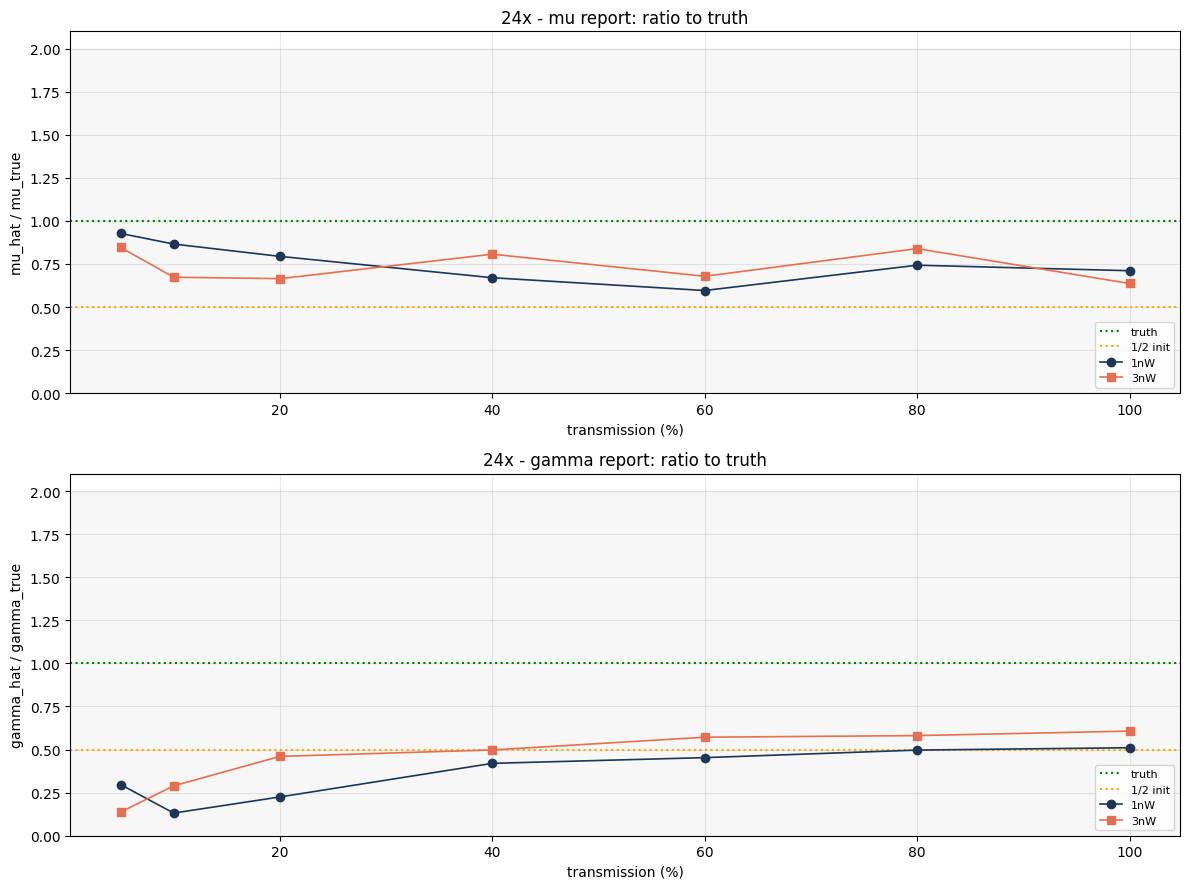

In [19]:
# ============================================================
# FIG 2 — the μ report (top) and the γ report (bottom): ratio to truth ± the Fisher CRB whisker.
#   22a's style; ONE panel per parameter, with the hue = laser power (1nW | 3nW).
#   Whisker = the dataset CRB (B): truth-inside = honesty.
# ============================================================
def _trow(power):
    return sorted([t for t in TABLE if t['exp'].startswith(power)],
                  key=lambda t: int(t['exp'].split('Trans')[-1]))

COL = {'1nW': '#1d3557', '3nW': '#e76f51'}
MK  = {'1nW': 'o-', '3nW': 's-'}
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
for ax, key in zip(axes, ['mu', 'gamma']):
    for power in POWERS:
        ts = _trow(power)
        xs = [int(t['exp'].split('Trans')[-1]) for t in ts]
        if key == 'mu':
            ys  = [t['mu'] / t['mu_true'] for t in ts]
            err = [t['sig_mu_data'] / t['mu_true'] for t in ts] if DO_FISHER else None
        else:
            ys  = [t['gamma'] / t['gamma_true'] for t in ts]
            err = [t['sig_g_data'] / t['gamma_true'] for t in ts] if DO_FISHER else None
        ax.errorbar(xs, ys, yerr=err, fmt=MK[power], color=COL[power], capsize=4, ms=6, lw=1.2,
                    label=(f'{power}   (whisker = Fisher sigma_{key})' if DO_FISHER else power))
    ax.axhline(1.0, color='g', ls=':', label='truth')
    ax.axhline(0.5, color='orange', ls=':', label='1/2 init')
    ax.axhspan(0.0, 2.0, color='gray', alpha=0.06)
    ax.set_xlabel('transmission (%)'); ax.set_ylabel(f'{key}_hat / {key}_true')
    ax.set_ylim(0, 2.1); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='lower right')
    ax.set_title(f"{NB_ID} - {key} report: ratio to truth" + (" with Fisher sigma whiskers (dataset CRB)" if DO_FISHER else ""))
fig.tight_layout(); plt.show()


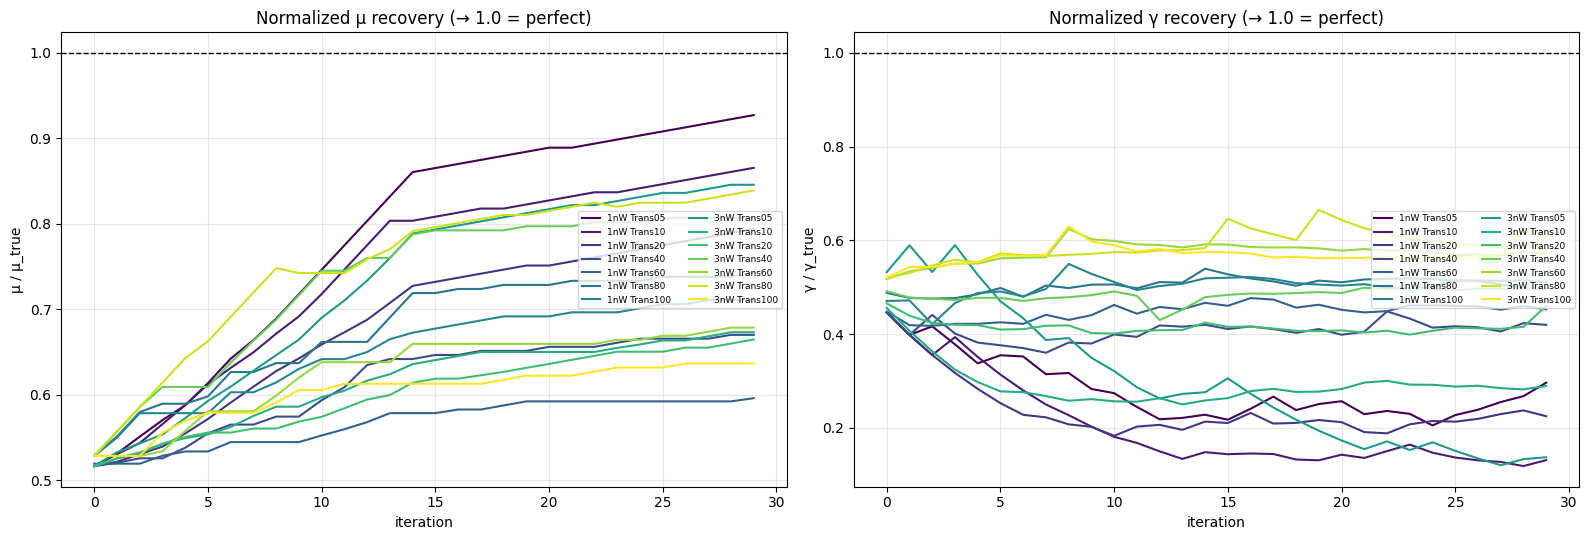

In [20]:
# ============================================================
# FIG 3 — normalized trajectories (μ/μ_true, γ/γ_true vs iteration); starts AT the 0.5x init
#   (22a verbatim)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
colors = plt.cm.viridis(np.linspace(0, 1, len(RESULTS)))
for r, c in zip(RESULTS, colors):
    st = [h['step'] for h in r['history']]
    axes[0].plot(st, [h['mu']    / r['mu_true']    for h in r['history']], color=c, lw=1.5, label=r['exp'])
    axes[1].plot(st, [h['gamma'] / r['gamma_true'] for h in r['history']], color=c, lw=1.5, label=r['exp'])
for ax, yl in [(axes[0], 'μ / μ_true'), (axes[1], 'γ / γ_true')]:
    ax.axhline(1.0, color='k', ls='--', lw=1); ax.set_xlabel('iteration'); ax.set_ylabel(yl); ax.grid(alpha=0.3)
    ax.legend(fontsize=6.5, ncol=2, loc='center right')
axes[0].set_title('Normalized μ recovery (→ 1.0 = perfect)')
axes[1].set_title('Normalized γ recovery (→ 1.0 = perfect)')
plt.tight_layout(); plt.show()


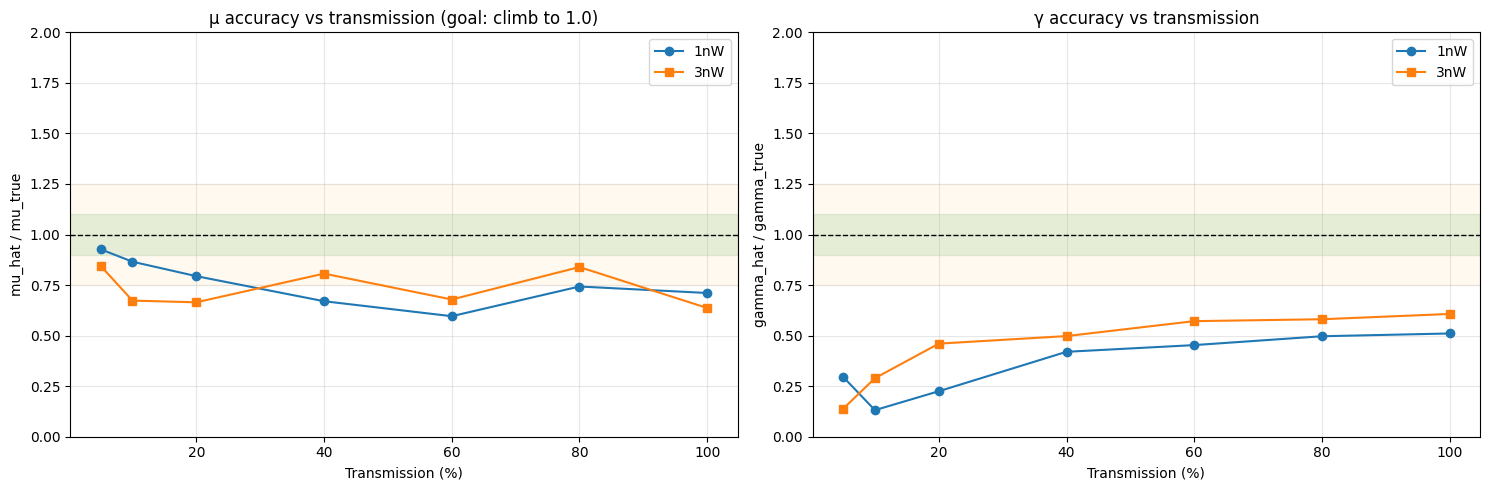

graded-goal check (ratio by transmission):
    T   mu(1nW)   mu(3nW)    g(1nW)    g(3nW)
    5     0.927     0.846     0.297     0.137
   10     0.866     0.673     0.131      0.29
   20     0.794     0.665     0.225      0.46
   40      0.67     0.807      0.42     0.498
   60     0.596     0.679     0.453     0.572
   80     0.743     0.839     0.497     0.581
  100     0.711     0.637     0.511     0.607


In [21]:
# ============================================================
# FIG 4 — accuracy vs transmission (goal: ratios climb toward 1.0 with T)   (22a verbatim)
# ============================================================
pows = ['1nW', '3nW']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, key in zip(axes, ['mu', 'gamma']):
    for p, mk in zip(pows, ['o-', 's-']):
        rs = sorted([r for r in RESULTS if r['power'] == p], key=lambda z: z['T'])
        if not rs: continue
        xs = [r['T'] for r in rs]
        ys = [(r['mu_final']/r['mu_true']) if key == 'mu' else (r['gamma_final']/r['gamma_true']) for r in rs]
        ax.plot(xs, ys, mk, label=p, ms=6)
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.axhspan(0.9, 1.1, color='green', alpha=0.10); ax.axhspan(0.75, 1.25, color='orange', alpha=0.06)
    ax.set_xlabel('Transmission (%)'); ax.set_ylabel(f'{key}_hat / {key}_true'); ax.set_ylim(0, 2.0)
    ax.grid(alpha=0.3); ax.legend()
axes[0].set_title('μ accuracy vs transmission (goal: climb to 1.0)')
axes[1].set_title('γ accuracy vs transmission')
plt.tight_layout(); plt.show()

print('graded-goal check (ratio by transmission):')
print(f"{'T':>5} {'mu(1nW)':>9} {'mu(3nW)':>9} {'g(1nW)':>9} {'g(3nW)':>9}")
for T in sorted({r['T'] for r in RESULTS}):
    row = [T]
    for p in pows:
        rs = [r for r in RESULTS if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['mu_final']/rs[0]['mu_true'], 3) if rs else float('nan'))
    for p in pows:
        rs = [r for r in RESULTS if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['gamma_final']/rs[0]['gamma_true'], 3) if rs else float('nan'))
    print(f"{row[0]:>5} {row[1]:>9} {row[2]:>9} {row[3]:>9} {row[4]:>9}")


In [22]:
if not DO_FISHER:
    print('DO_FISHER=False - FIG5 (Fisher ellipses) skipped')
else:
    # ============================================================
    # FIG 5 — FISHER ELLIPSES (1σ) in (μ, γ) at the fitted point
    #   21c's FIG 10, laid out as 2 columns (1nW | 3nW) × 7 rows (Trans05…Trans100).
    #   The ellipse is the dataset CRB (B). Variant A (per-scan) is a factor √N larger -> off-panel.
    # ============================================================
    from matplotlib.patches import Ellipse
    fig, axes = plt.subplots(7, 2, figsize=(12, 26))
    for ci, power in enumerate(POWERS):
        ts = _trow(power)
        for ri, t in enumerate(ts):
            ax = axes[ri][ci]
            sm, sg, corr = t['sig_mu_data'], t['sig_g_data'], t['corr']
            degenerate = sg < 1e-6                       # σ_γ → 0: the low-count Fisher degeneracy
            if not degenerate:
                cov = np.array([[sm**2, corr*sm*sg], [corr*sm*sg, sg**2]])
                lam_, vec = np.linalg.eigh(cov)
                ang = np.degrees(np.arctan2(vec[1, -1], vec[0, -1]))
                ax.add_patch(Ellipse((t['mu'], t['gamma']), 2*np.sqrt(lam_[0]), 2*np.sqrt(lam_[1]),
                                     angle=ang, facecolor='#457b9d', edgecolor='k', alpha=0.35, lw=0.8,
                                     label='Fisher CRB (1σ, dataset)'))
            ax.plot(t['mu'], t['gamma'], 'b.', ms=9, label='fit')
            ax.plot(t['mu_true'], t['gamma_true'], 'g*', ms=16, label='truth')
            dg_txt = 'σγ→0 (degenerate)' if degenerate else f"Δγ/σ={t['dg_sigma_data']:.1f}"
            ax.set_title(f"{t['exp']}  |  Δμ/σ={t['dmu_sigma_data']:.1f}   {dg_txt}", fontsize=8)
            ax.set_xlabel('μ (photons)'); ax.set_ylabel('γ (MHz)'); ax.grid(alpha=0.3); ax.legend(fontsize=6)
    plt.suptitle('23a — Fisher CRB ellipses (1σ, dataset) at the fitted point', fontsize=13)
    plt.tight_layout(); plt.show()

DO_FISHER=False - FIG5 (Fisher ellipses) skipped


## Verdict — the estimator-matched (pseudo-Voigt) forward model does **not** fix μ and wrecks γ (μ 27.1 % vs 24r 25.5 %; γ 61.4 % vs 35.1 %) — prediction FALSIFIED

`W_obj(all14) = 0.1953 | T>=40 0.1597 | T<=20 0.3044 | mu rel-RMSE 27.1 % | gamma rel-RMSE 61.4 % | diverged 0/14`
(vs 24r: 0.0672 / 0.0326 / 0.1735 / μ 25.5 % / γ 35.1 %; vs 24o's σ-only pv match: 0.0796 / 0.0353 / μ 28.6 % / γ 38.4 %.)

**(a) μ did not move toward truth — it moved *down*.** The per-cell μ/true table *deepens* the undershoot
(e.g. 1nW T60 0.596, 3nW T100 0.637, 1nW T40 0.670); μ rel-RMSE **27.1 %** (24r 25.5 %, 24o 28.6 %).  The best
cell is 1nW T05 (0.927).  So replacing the analytic Lorentzian CRLB with the pseudo-Voigt estimator at the
FWHM channel too does **not** fix the σ(μ) conditional at source.

**(b) γ collapses.** γ rel-RMSE **61.4 %** (worse than *every* A/B/C notebook); 1nW T10 γ/true 0.131, 3nW T05
0.137.  The cause is now doubly clear: the pv estimator's FWHM (Voigt FWHM via Olivero-Longbothum, inflated
~84 % at truth per 22g) *and* the pv σ channel (24o) both feed the γ score, and a coherent-but-wrong line model
pulls γ hard down.  24o's "the γ chain should not consume σ" is confirmed and extends to the FWHM channel: an
estimator-weighted γ chain is fragile.

**(c) Read.** Matching the estimator at the FWHM level is the wrong lever for μ (it is a *line-shape* mismatch,
FM#6, not an estimator mismatch) and it is actively harmful for γ.  The σ channel remains the only μ-side
lever, and even a "matched" σ channel (24o) only reaches μ 28.6 %.  This closes D1 negatively and motivates the
**calibrated** forms D2/D3, which keep the σ channel but correct its *value*, and the E1 role-split.

**Prediction: FALSIFIED.** (μ was predicted to improve; it did not.  γ was predicted to possibly pay; it paid
catastrophically.)

**Cost note (engineering):** one pv fit per run (3-parameter, n_iters=80) at the full protocol budget
(N_RUNS=100, N_ITER=30) — **92.7 min wall** (≈ 5.3–10 min/experiment, growing with the photon count).

**FM tag:** FM#8 (estimator part — does **not** fix μ) + FM#6 (line-shape weight in the γ chain).
**Next:** `24y` (D2) — a **smooth differentiable surrogate** σ = κ(FWHM,n,γ)·σ_CRLB calibrated to the
22g (real/estimator) σ map, keeping the cheap Lorentzian FWHM channel.


## Notes / caveats

- **Chaos band.** The objective is chaotically sensitive (~±0.01 for <1e-3 knob changes; integer photon
  rounding). Treat ≤0.005 differences as noise; repeat a winning config ≥2× before believing it.
- **Truth-free rule.** Every knob derived from data must come from the *target cloud* or the *sim cloud* —
  never from `mu_true`/`gamma_true`. (The protocol init `0.5 × truth` is the single documented exception
  and is a property of the protocol, not a tuned knob.)
- **One change per notebook**, stated in the markdown cell above the config; keep the rest byte-identical
  by **forking the previous notebook** (`cp 24x.ipynb 24y.ipynb`).
- Figures render inline (no `savefig`); FIG1 is exported to HTML for the browser. Run **in place**
  (`papermill 24x.ipynb 24x.ipynb`), never an `-executed` copy.
- Append the log row in `SERIES_STATE.md` §7 and commit+push after every notebook.
